In [1]:
from PIL import Image
import math
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.optim import Adam
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm

img_size = 32
batch_size = 128
num_timesteps = 1000
epochs = 1000
lr = 5e-4
device = 'cuda'


def show_images(images, rows=2, cols=10):
    fig = plt.figure(figsize=(cols, rows))
    i = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.axis('off')
            i += 1
    plt.show()


# 位置编码部分
def _pos_encoding(time_idx, output_dim, device='cpu'):
    """针对某一个时间步time_idx进行正弦位置编码"""
    t, D = time_idx, output_dim
    v = torch.zeros(D, device=device)

    i = torch.arange(0, D, device=device)
    div_term = torch.exp(i / D * math.log(10000))

    v[0::2] = torch.sin(t / div_term[0::2])
    v[1::2] = torch.cos(t / div_term[1::2])
    return v


def pos_encoding(timesteps, output_dim, device='cpu'):
    """针对一批时间步进行正弦位置编码"""
    batch_size = len(timesteps)
    device = timesteps.device
    v = torch.zeros(batch_size, output_dim, device=device)
    for i in range(batch_size):
        v[i] = _pos_encoding(timesteps[i], output_dim, device)
    return v


class ConvBlock(nn.Module):
    """卷积块"""

    def __init__(self, in_ch, out_ch, time_embed_dim):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        # 将时间步嵌入转换成和图像相同的形状
        self.mlp = nn.Sequential(
            nn.Linear(time_embed_dim, in_ch),
            nn.ReLU(),
            nn.Linear(in_ch, in_ch)
        )

    def forward(self, x, v):
        N, C, _, _ = x.shape  # shape: (批次大小N,通道数量C,高H,宽W)
        v = self.mlp(v)
        v = v.view(N, C, 1, 1)
        y = self.convs(x + v)
        return y


class UNet(nn.Module):
    def __init__(self, in_ch=3, time_embed_dim=100):
        super().__init__()
        self.time_embed_dim = time_embed_dim

        self.down1 = ConvBlock(in_ch, 64, time_embed_dim)
        self.down2 = ConvBlock(64, 128, time_embed_dim)
        self.bot1 = ConvBlock(128, 256, time_embed_dim)
        self.up2 = ConvBlock(128 + 256, 128, time_embed_dim)
        self.up1 = ConvBlock(128 + 64, 64, time_embed_dim)
        self.out = nn.Conv2d(64, in_ch, 1)

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x, timesteps):
        v = pos_encoding(timesteps, self.time_embed_dim, x.device)

        x1 = self.down1(x, v)
        x = self.maxpool(x1)
        x2 = self.down2(x, v)
        x = self.maxpool(x2)

        x = self.bot1(x, v)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, v)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, v)
        x = self.out(x)
        return x


class Diffuser:
    def __init__(self,
                 num_timesteps=1000,  # 时间步T=1000
                 beta_start=0.0001,  # 方差的起始值β_0 = 0.0001
                 beta_end=0.02,  # 方差的最终值β_T = 0.02
                 device='cpu'
                 ):
        self.num_timesteps = num_timesteps
        self.device = device
        # 方差调度计划[β_1, β_2, β_3,...]
        self.betas = torch.linspace(
            beta_start,
            beta_end,
            num_timesteps,
            device=device
        )
        # α_t = 1 - β_t
        # [α_1, α_2, ....]
        self.alphas = 1 - self.betas
        # α_bar_t = α_t * α_{t-1} * ... * α_1
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x_0, t):
        """添加噪声，将x_0直接变成x_t"""
        """闭式解，解析解"""
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all()

        t_idx = t - 1  # alpha_bars[0] is for t=1
        alpha_bar = self.alpha_bars[t_idx]  # (N,)
        N = alpha_bar.size(0)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)  # (N, 1, 1, 1)

        noise = torch.randn_like(x_0, device=self.device)
        x_t = torch.sqrt(alpha_bar) * x_0 \
              + torch.sqrt(1 - alpha_bar) * noise
        return x_t, noise

    def denoise(self, model, x, t):
        """去除一步噪声，将x_t变成x_{t-1}"""
        # x_t, t
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all()

        t_idx = t - 1  # alphas[0] is for t=1
        alpha = self.alphas[t_idx]
        alpha_bar = self.alpha_bars[t_idx]
        alpha_bar_prev = self.alpha_bars[t_idx - 1]

        N = alpha.size(0)
        alpha = alpha.view(N, 1, 1, 1)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(N, 1, 1, 1)

        model.eval()
        with torch.no_grad():
            eps = model(x, t)
        model.train()

        noise = torch.randn_like(x, device=self.device)
        noise[t == 1] = 0  # no noise at t=1

        mu = (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps) \
             / torch.sqrt(alpha)
        std = torch.sqrt(
            (1 - alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar)
        )
        # x_{t-1}
        return mu + noise * std

    def reverse_to_img(self, x):
        """将像素点变成图片"""
        x = (x + 1) / 2
        x = x * 255
        x = x.clamp(0, 255)
        x = x.to(torch.uint8)
        x = x.cpu()
        to_pil = transforms.ToPILImage()
        return to_pil(x)

    def sample(self, model, x_shape=(20, 3, 32, 32)):
        """从纯噪声图片x_1000反向扩散出x_0"""
        batch_size = x_shape[0]
        # 采样一张白噪声图片x_1000出来
        x = torch.randn(x_shape, device=self.device)
        # for t = T, T-1, ..., 0
        for i in tqdm(range(self.num_timesteps, 0, -1)):
            t = torch.tensor(
                [i] * batch_size,
                device=self.device,
                dtype=torch.long
            )
            # 一步去噪，x_t --> x_{t-1}
            x = self.denoise(model, x, t)

        images = [
            self.reverse_to_img(x[i])
            for i in range(batch_size)
        ]
        return images

Epoch 0 | Loss: 1.1845550537109375
Epoch 1 | Loss: 1.00634765625
Epoch 2 | Loss: 0.9055440425872803
Epoch 3 | Loss: 0.7654878497123718
Epoch 4 | Loss: 0.655914306640625
Epoch 5 | Loss: 0.5541204214096069
Epoch 6 | Loss: 0.5067395567893982
Epoch 7 | Loss: 0.45226818323135376
Epoch 8 | Loss: 0.4087340235710144
Epoch 9 | Loss: 0.3533969819545746
Epoch 10 | Loss: 0.30540913343429565
Epoch 11 | Loss: 0.303426593542099
Epoch 12 | Loss: 0.2725907266139984
Epoch 13 | Loss: 0.24932846426963806
Epoch 14 | Loss: 0.24728450179100037
Epoch 15 | Loss: 0.23310914635658264
Epoch 16 | Loss: 0.21590447425842285
Epoch 17 | Loss: 0.21753481030464172
Epoch 18 | Loss: 0.20272593200206757
Epoch 19 | Loss: 0.19300666451454163
Epoch 20 | Loss: 0.18427452445030212
Epoch 21 | Loss: 0.16882503032684326
Epoch 22 | Loss: 0.15372872352600098
Epoch 23 | Loss: 0.15470238029956818
Epoch 24 | Loss: 0.15302160382270813
Epoch 25 | Loss: 0.13738732039928436
Epoch 26 | Loss: 0.13308122754096985
Epoch 27 | Loss: 0.1389578878

100%|██████████| 1000/1000 [00:25<00:00, 38.81it/s]


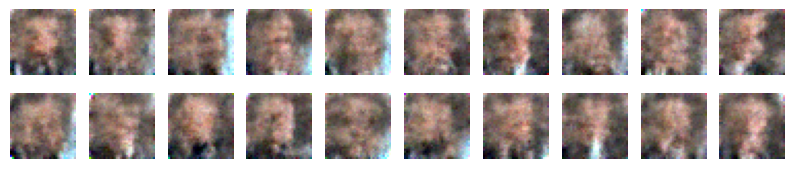

Epoch 99 | Loss: 0.07376082241535187
Epoch 100 | Loss: 0.06267600506544113
Epoch 101 | Loss: 0.07419657707214355
Epoch 102 | Loss: 0.06363440304994583
Epoch 103 | Loss: 0.06523549556732178
Epoch 104 | Loss: 0.06648200750350952
Epoch 105 | Loss: 0.06937980651855469
Epoch 106 | Loss: 0.05830466374754906
Epoch 107 | Loss: 0.06976652890443802
Epoch 108 | Loss: 0.05369296297430992
Epoch 109 | Loss: 0.06209221109747887
Epoch 110 | Loss: 0.07588793337345123
Epoch 111 | Loss: 0.07261896878480911
Epoch 112 | Loss: 0.0594036802649498
Epoch 113 | Loss: 0.06293980777263641
Epoch 114 | Loss: 0.059605877846479416
Epoch 115 | Loss: 0.07292991876602173
Epoch 116 | Loss: 0.07037346065044403
Epoch 117 | Loss: 0.0584866963326931
Epoch 118 | Loss: 0.05788014829158783
Epoch 119 | Loss: 0.06350059807300568
Epoch 120 | Loss: 0.06038745865225792
Epoch 121 | Loss: 0.05526991933584213
Epoch 122 | Loss: 0.07745643705129623
Epoch 123 | Loss: 0.05992603302001953
Epoch 124 | Loss: 0.056547969579696655
Epoch 125 | L

100%|██████████| 1000/1000 [00:25<00:00, 38.90it/s]


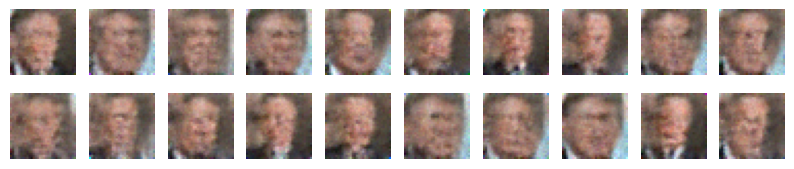

Epoch 199 | Loss: 0.03797789663076401
Epoch 200 | Loss: 0.0543365404009819
Epoch 201 | Loss: 0.04571625590324402
Epoch 202 | Loss: 0.046229928731918335
Epoch 203 | Loss: 0.04208628460764885
Epoch 204 | Loss: 0.050820332020521164
Epoch 205 | Loss: 0.043289463967084885
Epoch 206 | Loss: 0.05387035012245178
Epoch 207 | Loss: 0.04601365327835083
Epoch 208 | Loss: 0.048568129539489746
Epoch 209 | Loss: 0.050960343331098557
Epoch 210 | Loss: 0.03984622284770012
Epoch 211 | Loss: 0.05042601376771927
Epoch 212 | Loss: 0.05439945310354233
Epoch 213 | Loss: 0.041726142168045044
Epoch 214 | Loss: 0.03868299350142479
Epoch 215 | Loss: 0.048211317509412766
Epoch 216 | Loss: 0.038740333169698715
Epoch 217 | Loss: 0.05104973167181015
Epoch 218 | Loss: 0.03919488936662674
Epoch 219 | Loss: 0.043876029551029205
Epoch 220 | Loss: 0.04985489696264267
Epoch 221 | Loss: 0.043414633721113205
Epoch 222 | Loss: 0.04356195032596588
Epoch 223 | Loss: 0.04083896428346634
Epoch 224 | Loss: 0.04475458711385727
Epo

100%|██████████| 1000/1000 [00:37<00:00, 26.84it/s]


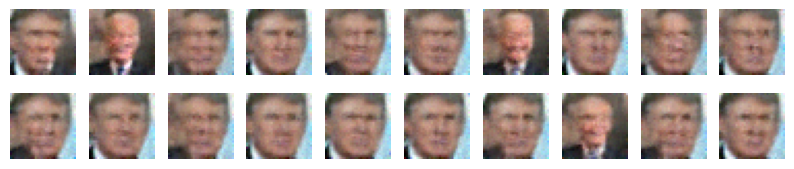

Epoch 299 | Loss: 0.03903666138648987
Epoch 300 | Loss: 0.04049528390169144
Epoch 301 | Loss: 0.03518589586019516
Epoch 302 | Loss: 0.03514600545167923
Epoch 303 | Loss: 0.03204119950532913
Epoch 304 | Loss: 0.03018397092819214
Epoch 305 | Loss: 0.03815336525440216
Epoch 306 | Loss: 0.03771154209971428
Epoch 307 | Loss: 0.037751976400613785
Epoch 308 | Loss: 0.03714151680469513
Epoch 309 | Loss: 0.04203104227781296
Epoch 310 | Loss: 0.0326792411506176
Epoch 311 | Loss: 0.03710567206144333
Epoch 312 | Loss: 0.028498314321041107
Epoch 313 | Loss: 0.03879551589488983
Epoch 314 | Loss: 0.0436406247317791
Epoch 315 | Loss: 0.03247177600860596
Epoch 316 | Loss: 0.03581036254763603
Epoch 317 | Loss: 0.032219450920820236
Epoch 318 | Loss: 0.033440783619880676
Epoch 319 | Loss: 0.04027121514081955
Epoch 320 | Loss: 0.03234231472015381
Epoch 321 | Loss: 0.038454316556453705
Epoch 322 | Loss: 0.03719552978873253
Epoch 323 | Loss: 0.035295452922582626
Epoch 324 | Loss: 0.03010348230600357
Epoch 32

100%|██████████| 1000/1000 [00:47<00:00, 21.17it/s]


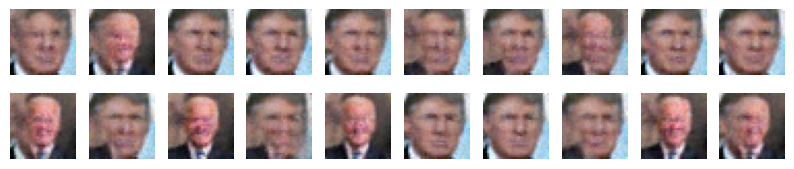

Epoch 399 | Loss: 0.03269786387681961
Epoch 400 | Loss: 0.02952122688293457
Epoch 401 | Loss: 0.026910532265901566
Epoch 402 | Loss: 0.028355401009321213
Epoch 403 | Loss: 0.030943963676691055
Epoch 404 | Loss: 0.03190077468752861
Epoch 405 | Loss: 0.02601008117198944
Epoch 406 | Loss: 0.030986830592155457
Epoch 407 | Loss: 0.02750815823674202
Epoch 408 | Loss: 0.029635801911354065
Epoch 409 | Loss: 0.03279602527618408
Epoch 410 | Loss: 0.03746774047613144
Epoch 411 | Loss: 0.03336223587393761
Epoch 412 | Loss: 0.03691909834742546
Epoch 413 | Loss: 0.035658098757267
Epoch 414 | Loss: 0.03024466335773468
Epoch 415 | Loss: 0.025666242465376854
Epoch 416 | Loss: 0.029491044580936432
Epoch 417 | Loss: 0.027289431542158127
Epoch 418 | Loss: 0.024638911709189415
Epoch 419 | Loss: 0.02299024537205696
Epoch 420 | Loss: 0.031027084216475487
Epoch 421 | Loss: 0.02740209922194481
Epoch 422 | Loss: 0.02710617147386074
Epoch 423 | Loss: 0.026976630091667175
Epoch 424 | Loss: 0.0300721675157547
Epoc

100%|██████████| 1000/1000 [00:50<00:00, 19.99it/s]


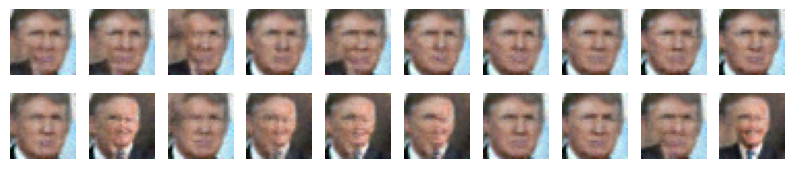

Epoch 499 | Loss: 0.024947550147771835
Epoch 500 | Loss: 0.024075819179415703
Epoch 501 | Loss: 0.0239618681371212
Epoch 502 | Loss: 0.02333887480199337
Epoch 503 | Loss: 0.026513393968343735
Epoch 504 | Loss: 0.020040586590766907
Epoch 505 | Loss: 0.023997871205210686
Epoch 506 | Loss: 0.026361187919974327
Epoch 507 | Loss: 0.022464033216238022
Epoch 508 | Loss: 0.02609102986752987
Epoch 509 | Loss: 0.022802170366048813
Epoch 510 | Loss: 0.027419790625572205
Epoch 511 | Loss: 0.022288290783762932
Epoch 512 | Loss: 0.019729670137166977
Epoch 513 | Loss: 0.030615856871008873
Epoch 514 | Loss: 0.030774414539337158
Epoch 515 | Loss: 0.02629903331398964
Epoch 516 | Loss: 0.030367407947778702
Epoch 517 | Loss: 0.023918673396110535
Epoch 518 | Loss: 0.02825552225112915
Epoch 519 | Loss: 0.028661316260695457
Epoch 520 | Loss: 0.025746649131178856
Epoch 521 | Loss: 0.032689645886421204
Epoch 522 | Loss: 0.023543303832411766
Epoch 523 | Loss: 0.02306225895881653
Epoch 524 | Loss: 0.025631353259

100%|██████████| 1000/1000 [00:34<00:00, 28.90it/s]


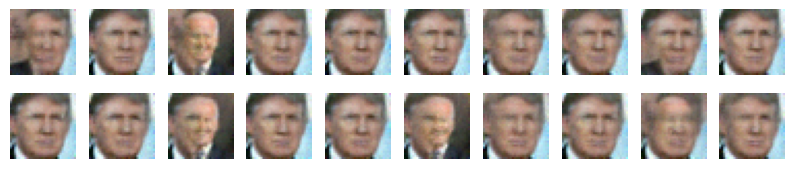

Epoch 599 | Loss: 0.029705923050642014
Epoch 600 | Loss: 0.024614255875349045
Epoch 601 | Loss: 0.028519511222839355
Epoch 602 | Loss: 0.025257928296923637
Epoch 603 | Loss: 0.029874613508582115
Epoch 604 | Loss: 0.022214636206626892
Epoch 605 | Loss: 0.0258261077105999
Epoch 606 | Loss: 0.021178651601076126
Epoch 607 | Loss: 0.029791023582220078
Epoch 608 | Loss: 0.03051239252090454
Epoch 609 | Loss: 0.021879971027374268
Epoch 610 | Loss: 0.02254762314260006
Epoch 611 | Loss: 0.03018966317176819
Epoch 612 | Loss: 0.021381264552474022
Epoch 613 | Loss: 0.02834627777338028
Epoch 614 | Loss: 0.0238801296800375
Epoch 615 | Loss: 0.02023031935095787
Epoch 616 | Loss: 0.021961569786071777
Epoch 617 | Loss: 0.0223089512437582
Epoch 618 | Loss: 0.01783742383122444
Epoch 619 | Loss: 0.02764943614602089
Epoch 620 | Loss: 0.026548510417342186
Epoch 621 | Loss: 0.022437356412410736
Epoch 622 | Loss: 0.033519260585308075
Epoch 623 | Loss: 0.025847937911748886
Epoch 624 | Loss: 0.023259062319993973

100%|██████████| 1000/1000 [00:37<00:00, 26.45it/s]


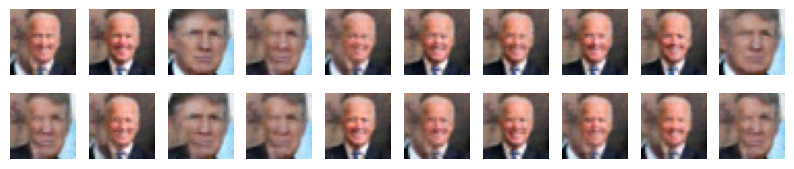

Epoch 699 | Loss: 0.01902012526988983
Epoch 700 | Loss: 0.023730792105197906
Epoch 701 | Loss: 0.02091933600604534
Epoch 702 | Loss: 0.025814712047576904
Epoch 703 | Loss: 0.0221550352871418
Epoch 704 | Loss: 0.023861084133386612
Epoch 705 | Loss: 0.02478155307471752
Epoch 706 | Loss: 0.023837994784116745
Epoch 707 | Loss: 0.022247914224863052
Epoch 708 | Loss: 0.019678764045238495
Epoch 709 | Loss: 0.02030307799577713
Epoch 710 | Loss: 0.021635254845023155
Epoch 711 | Loss: 0.021339138969779015
Epoch 712 | Loss: 0.0203765369951725
Epoch 713 | Loss: 0.02040090411901474
Epoch 714 | Loss: 0.02244552969932556
Epoch 715 | Loss: 0.020746923983097076
Epoch 716 | Loss: 0.018933895975351334
Epoch 717 | Loss: 0.027304671704769135
Epoch 718 | Loss: 0.024016214534640312
Epoch 719 | Loss: 0.022018738090991974
Epoch 720 | Loss: 0.01979857310652733
Epoch 721 | Loss: 0.018674515187740326
Epoch 722 | Loss: 0.026434581726789474
Epoch 723 | Loss: 0.018410608172416687
Epoch 724 | Loss: 0.0159360151737928

100%|██████████| 1000/1000 [00:32<00:00, 31.03it/s]


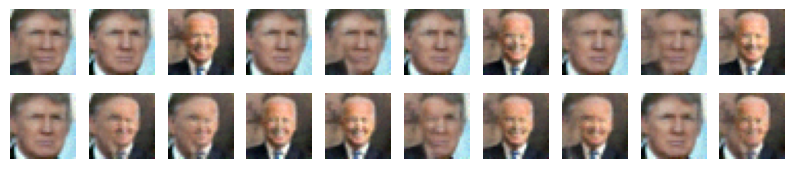

Epoch 799 | Loss: 0.022619491443037987
Epoch 800 | Loss: 0.017941925674676895
Epoch 801 | Loss: 0.021159783005714417
Epoch 802 | Loss: 0.02358740195631981
Epoch 803 | Loss: 0.018917854875326157
Epoch 804 | Loss: 0.02174866944551468
Epoch 805 | Loss: 0.02187669835984707
Epoch 806 | Loss: 0.021157613024115562
Epoch 807 | Loss: 0.014438046142458916
Epoch 808 | Loss: 0.024983173236250877
Epoch 809 | Loss: 0.02098655328154564
Epoch 810 | Loss: 0.021673455834388733
Epoch 811 | Loss: 0.017477670684456825
Epoch 812 | Loss: 0.014978645369410515
Epoch 813 | Loss: 0.015736639499664307
Epoch 814 | Loss: 0.01718764938414097
Epoch 815 | Loss: 0.018118295818567276
Epoch 816 | Loss: 0.01849733293056488
Epoch 817 | Loss: 0.01602649688720703
Epoch 818 | Loss: 0.018356401473283768
Epoch 819 | Loss: 0.02223038487136364
Epoch 820 | Loss: 0.019300781190395355
Epoch 821 | Loss: 0.019337326288223267
Epoch 822 | Loss: 0.01783808320760727
Epoch 823 | Loss: 0.014383865520358086
Epoch 824 | Loss: 0.01665819622576

100%|██████████| 1000/1000 [00:32<00:00, 30.63it/s]


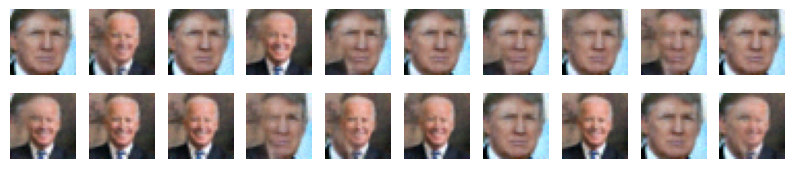

Epoch 899 | Loss: 0.017966413870453835
Epoch 900 | Loss: 0.012416576966643333
Epoch 901 | Loss: 0.019434427842497826
Epoch 902 | Loss: 0.017656397074460983
Epoch 903 | Loss: 0.016143418848514557
Epoch 904 | Loss: 0.01767975464463234
Epoch 905 | Loss: 0.01886475831270218
Epoch 906 | Loss: 0.021995147690176964
Epoch 907 | Loss: 0.016054989770054817
Epoch 908 | Loss: 0.020039740949869156
Epoch 909 | Loss: 0.02138819359242916
Epoch 910 | Loss: 0.01938287355005741
Epoch 911 | Loss: 0.01815728098154068
Epoch 912 | Loss: 0.023662179708480835
Epoch 913 | Loss: 0.02144806832075119
Epoch 914 | Loss: 0.014238066039979458
Epoch 915 | Loss: 0.02267724834382534
Epoch 916 | Loss: 0.014842696487903595
Epoch 917 | Loss: 0.024046171456575394
Epoch 918 | Loss: 0.019137190654873848
Epoch 919 | Loss: 0.019373662769794464
Epoch 920 | Loss: 0.017830610275268555
Epoch 921 | Loss: 0.01550022792071104
Epoch 922 | Loss: 0.01336535345762968
Epoch 923 | Loss: 0.016880234703421593
Epoch 924 | Loss: 0.01780290156602

100%|██████████| 1000/1000 [00:32<00:00, 31.09it/s]


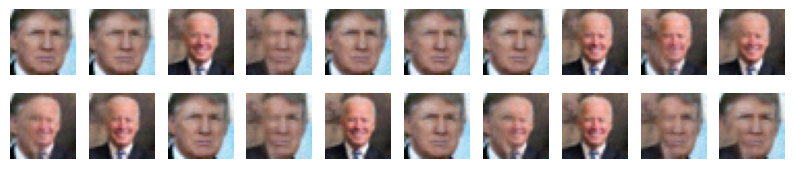

Epoch 999 | Loss: 0.018109839409589767


In [2]:
preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),  # Resize the input image
    transforms.ToTensor(),  # Convert to torch tensor (scales data into [0,1])
    transforms.Lambda(lambda t: (t * 2) - 1),  # Scale data between [-1, 1]
])
image_trump = Image.open("trump.jpeg")
image_trump = preprocess(image_trump).to(device)
image_biden = Image.open("biden.jpeg")
image_biden = preprocess(image_biden).to(device)

diffuser = Diffuser(num_timesteps, device=device)
model = UNet()
model.to(device)
optimizer = Adam(model.parameters(), lr=lr)

losses = []
for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0

    # 每个 epoch 都生成采样的图像 =======================
    if (epoch + 1) % 100 == 0:
        images = diffuser.sample(model)
        show_images(images)
    # ================================================
    # 将两张图片各复制128次，然后变成一个批次
    images = torch.stack([image_trump] * batch_size +
                         [image_biden] * batch_size)
    optimizer.zero_grad()
    x = images.to(device)
    # 随机取一个时间步
    t = torch.randint(1, num_timesteps + 1, (len(x),), device=device)
    # x_noisy是x_t，noise是添加的真正的噪声
    x_noisy, noise = diffuser.add_noise(x, t)
    # 模型根据x_t和时间步t，预测给x_t添加的噪声
    noise_pred = model(x_noisy, t)
    # 添加的真实噪声和预测噪声之间进行均方误差计算
    loss = F.mse_loss(noise, noise_pred)

    loss.backward()
    optimizer.step()

    loss_sum += loss.item()
    cnt += 1

    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(f'Epoch {epoch} | Loss: {loss_avg}')

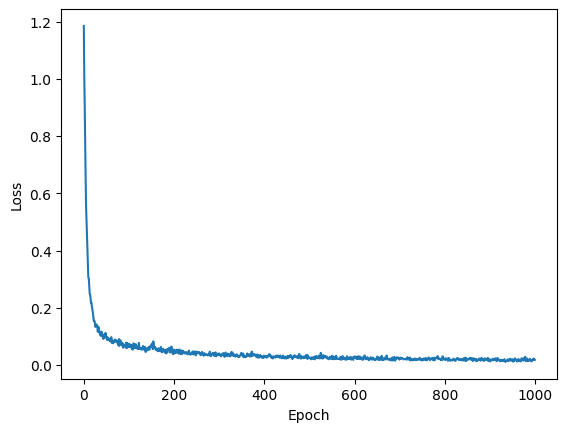

In [3]:
# 画出损失
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

100%|██████████| 1000/1000 [00:36<00:00, 27.75it/s]


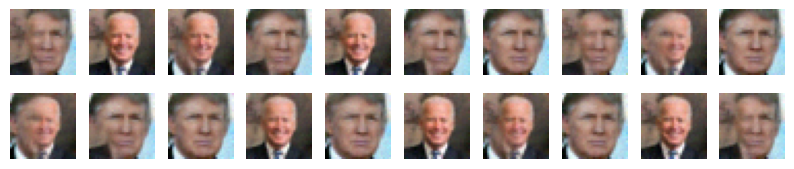

In [4]:
# 从完全噪声的图片反向扩散
images = diffuser.sample(model)
show_images(images)

# q(x_t|x_{t-1}), q(x_{t-1}|x_t), q(x_0)